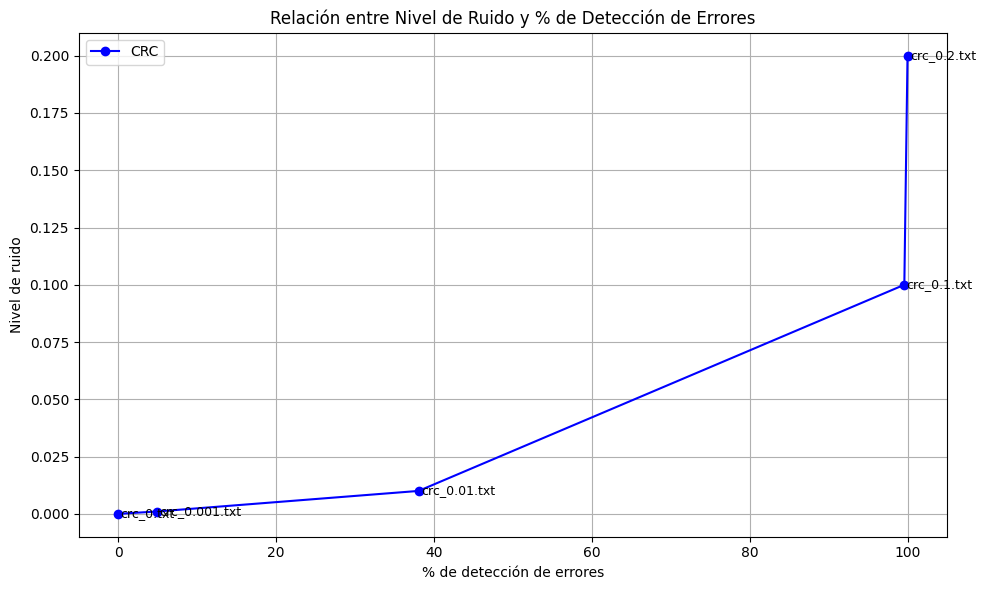

In [5]:
import matplotlib.pyplot as plt

# Lista de niveles de ruido y sus archivos correspondientes
archivos_crc = [
    (0, 'crc_0.txt'),
    (0.001, 'crc_0.001.txt'),
    (0.01, 'crc_0.01.txt'),
    (0.1, 'crc_0.1.txt'),
    (0.2, 'crc_0.2.txt'),
]

# Leer archivo base
with open('pruebas.txt', 'r') as f:
    original = f.read().splitlines()

# Función para calcular % de detección de errores (n * 100) / 247
def calcular_porcentaje_crc(archivo_crc, original):
    with open(archivo_crc, 'r') as f:
        comparado = f.read().splitlines()

    n = sum(1 for a, b in zip(original, comparado) if b.strip() == "0")
    porcentaje = (n * 100) / 247
    return porcentaje

# Calcular los valores para la gráfica
porcentajes = []
niveles_ruido = []
etiquetas = []

for nivel, archivo in archivos_crc:
    porcentaje = calcular_porcentaje_crc(archivo, original)
    porcentajes.append(porcentaje)
    niveles_ruido.append(nivel)
    etiquetas.append(archivo)

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(porcentajes, niveles_ruido, marker='o', linestyle='-', color='blue', label='CRC')

# Añadir etiquetas en cada punto
for x, y, etiqueta in zip(porcentajes, niveles_ruido, etiquetas):
    plt.text(x + 0.3, y, etiqueta, fontsize=9, verticalalignment='center')

# Configuración de la gráfica
plt.xlabel('% de detección de errores')
plt.ylabel('Nivel de ruido')
plt.title('Relación entre Nivel de Ruido y % de Detección de Errores')
plt.grid(True)
plt.legend()  # <<-- Aquí se muestra la leyenda con el nombre de la línea
plt.tight_layout()
plt.show()
